# ETFs: model-based features

The features built in `03_financial_features` are arithmetic on past bars: a 21-day return is
the same function of the same twenty-two prices whoever computes it. The features built here
are not. Each one is the output of a statistical model whose parameters were themselves
estimated from bars, so the stretch of history the model was fitted on becomes part of what
the feature knows. This notebook fits three such models and writes what they infer.

- A **hidden Markov model** on the broad US equity market, which infers whether each session
  is a calm one or a stressed one.
- **Fractional differencing** of ten reference ETF price series, a filter that removes enough
  of a price's trend to make it statistically stable while keeping some of its long memory.
- A **GARCH(1,1)** volatility model per ETF, which infers how volatile each asset is on each
  session given how it has moved so far.

Every fit happens inside one cross-validation fold, on that fold's training sessions only, and
every row of the output carries the number of the fold whose model produced it.

## Learning objectives

By the end of this notebook you will be able to:

- Explain why a feature computed from a fitted model can read the future even when the
  formula behind it only looks backwards, and name the two places that happens.
- Split a price history into walk-forward training and validation windows, and estimate a
  model separately inside each one so that no parameter is informed by the window it is
  scored on.
- Run a hidden Markov model forward through a series so that the state it reports for a given
  session depends only on that session and the ones before it, rather than on the whole
  series at once.
- Difference a price series by a fractional amount, and check with a statistical test whether
  the result is stable enough to use as a model input.
- Fit a volatility model on training sessions, freeze its coefficients, and run the volatility
  recursion forward over later sessions without re-estimating anything.
- Write a feature table that records which fold produced each row, and check before writing it
  that the table has one row per asset per session and no missing folds.

## Book reference

Chapter 9, on fractional differencing, volatility models and regime features. Chapter 9 states
the requirement this whole stage exists to satisfy: an estimate must be generated using only
information available at the time of decision, re-estimated within the walk-forward protocol,
and versioned alongside the features it produces.

## Prerequisites

- [`02_labels`](02_labels.ipynb) writes the forward-return files. This notebook reads the
  primary one twice: once to fix the fold boundaries, and once at the end to measure whether
  the features it built rank anything.
- [`03_financial_features`](03_financial_features.ipynb) writes the arithmetic features.
  Chapter 11 joins that table to the one written here; neither reads the other.

In [1]:
"""ETFs: model-based features from per-fold HMM, fractional differencing and GARCH fits."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import yaml
from arch import arch_model
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr, robust_ic
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.engineer.features.fdiff import ffdiff
from statsmodels.tsa.stattools import adfuller
from threadpoolctl import threadpool_limits

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.cv_window import (
    assert_variant_folds_are_out_of_sample,
    configured_labels,
    modeling_fold_boundaries,
)
from case_studies.utils.temporal import (
    filtered_state_probs,
    fit_hmm_kmeans_init,
    sort_states_by_variance,
)
from data import load_etfs
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.modeling import resolve_label_buffer, resolve_label_horizon
from utils.paths import REPO_ROOT, display_path, get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
# Production defaults. Papermill overrides these for the reduced continuous-integration run.
CASE_STUDY_ID = "etfs"
SEED = 42
N_RESTARTS = 10
GARCH_MIN_OBS = 504
MAX_SYMBOLS = 0

## Configuration

Everything below that decides an estimation window, a boundary or a horizon is read from the
case study's `setup.yaml` rather than typed here, so that changing the configuration changes
what this notebook computes.

In [3]:
set_global_seeds(SEED)

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
LABEL_HORIZON = resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
LABEL_HORIZON_DAYS = int(str(LABEL_HORIZON).rstrip("Dd"))

# The HMM reads a realized-volatility series alongside returns. It uses the shortest window the
# case study declares for volatility, so the regime model and the stage-03 volatility features
# describe the same span of market history.
VOL_WINDOW = min(SETUP["features"]["windows"]["volatility"])

# The largest basket the strategy ever holds. A rank correlation computed across fewer names
# than that is not measuring an ordering the strategy could act on, so those sessions are
# dropped from the evaluation at the end.
MIN_CROSS_SECTION = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])

# The serial-dependence correction on the coefficient series uses lags out to the label horizon,
# so the series needs to be several times that long before the correction means anything.
MIN_IC_SESSIONS = 3 * LABEL_HORIZON_DAYS

EVAL_CONFIG = load_evaluation_config(CASE_STUDY_ID)
HOLDOUT_START = str(EVAL_CONFIG["holdout_start"])
HOLDOUT_END = str(EVAL_CONFIG["holdout_end"])

print(
    f"Target: {PRIMARY_LABEL}, a return realized {LABEL_HORIZON_DAYS} trading sessions after the "
    "session it is attached to."
)
print(
    f"Gap between the last training session and the first validation session: {LABEL_BUFFER}. "
    "It is the label horizon, so no training session's outcome is still unresolved when "
    "validation starts."
)
print(
    f"Regime model reads {VOL_WINDOW}-session realized volatility, the shortest volatility "
    "window this case study declares."
)
print(
    f"Sessions before {HOLDOUT_START} are available for development; {HOLDOUT_START} to "
    f"{HOLDOUT_END} is the holdout and is read once, in the final notebook of the case study."
)
print(
    f"A validation session needs at least {MIN_CROSS_SECTION} ETFs quoting to be scored - the "
    f"largest basket the strategy holds - and at least {MIN_IC_SESSIONS} such sessions before "
    "the coefficient across them is corrected for serial dependence."
)
print(
    f"GARCH is fitted only where a fold offers {GARCH_MIN_OBS} training sessions, about two years."
)
print(
    f"Walk-forward design: {EVAL_CONFIG['n_splits']} folds, each training on a rolling "
    f"{EVAL_CONFIG['train_size']} window and validating on the {EVAL_CONFIG['val_size']} "
    "that follows the purge."
)
print(
    f"The regime model is refitted from {N_RESTARTS} starting points per fold, keeping the "
    "one that fits its training window best."
)

Target: fwd_ret_21d, a return realized 21 trading sessions after the session it is attached to.
Gap between the last training session and the first validation session: 21D. It is the label horizon, so no training session's outcome is still unresolved when validation starts.
Regime model reads 21-session realized volatility, the shortest volatility window this case study declares.
Sessions before 2024-01-01 are available for development; 2024-01-01 to 2025-12-31 is the holdout and is read once, in the final notebook of the case study.
A validation session needs at least 20 ETFs quoting to be scored - the largest basket the strategy holds - and at least 63 such sessions before the coefficient across them is corrected for serial dependence.
GARCH is fitted only where a fold offers 504 training sessions, about two years.
Walk-forward design: 8 folds, each training on a rolling 10Y window and validating on the 1Y that follows the purge.
The regime model is refitted from 10 starting points p

## A. Why a fitted feature is different

A financial feature is a function of past bars. Compute a 21-session return on Tuesday and you
get the same number you would have got on Tuesday, because the arithmetic reaches back and
never forward.

A model-based feature is a function of *parameters estimated from* bars, and that adds a
second channel through which the future can reach a value that looks backward-facing. Two
things have to hold, not one:

**The parameters must come from the past.** Fit a volatility model once over the whole history
and its coefficients have read every crash in the sample. Apply them to 2008 and the 2008
volatility they produce is partly a memory of 2020. Nothing in the formula looks forward; the
coefficients did the looking. The fix is to estimate the parameters separately inside each
fold, on that fold's training sessions only, which is what the fold loops below do.

**The inference must also come from the past.** This one is easier to miss, because it
outlives a correct fit. Given fixed parameters, most of these models can be run two ways over
a series. The *filtered* pass reports, for each session, what the model concludes from that
session and the ones before it. The *smoothed* pass reports what the model concludes from the
entire series, so its answer for 2008 is revised once it has seen 2020. Both are legitimate
statistics and the smoothed one is usually the more accurate description of what happened.
Only the filtered one is available to someone standing in 2008, so only the filtered one can
be a feature.

The hidden Markov model below is where both channels are live, and its library offers the
smoothed pass as the convenient default. The section that fits it says which pass it uses and
why.

### The data these models run on

Before fitting anything, look at the panel. The universe is a hundred exchange-traded funds
assembled to cover the asset classes a diversified investor can reach through them, and the
download configuration that defines it groups them into nine categories. The table below is
that grouping, with the history each category actually has on disk.

Two things in it decide what happens further down. The panel is **unbalanced**: several of
these funds launched well after the sample begins, so the number quoting on a session grows
through the history. That is why the volatility model fits fewer assets in the earliest folds
than in the latest ones. And the categories are **not equally sized**: a cross-sectional
ranking over this universe is dominated by equities, because more than half the names are
equity funds of one kind or another.

In [4]:
prices = load_etfs()

_universe_cfg = yaml.safe_load(
    (REPO_ROOT / "data" / "etfs" / "market" / "config.yaml").read_text()
)["etfs"]["tickers"]
category_of = {sym: name for name, block in _universe_cfg.items() for sym in block["symbols"]}

universe = (
    prices.group_by("symbol")
    .agg(
        pl.col("timestamp").min().alias("first_session"),
        pl.col("timestamp").max().alias("last_session"),
        pl.len().alias("sessions"),
    )
    .with_columns(category=pl.col("symbol").replace_strict(category_of, default="uncategorised"))
)
assert not universe.filter(pl.col("category") == "uncategorised").height, (
    "an ETF in the price panel is missing from the universe configuration"
)

display(
    universe.group_by("category")
    .agg(
        pl.len().alias("ETFs"),
        pl.col("first_session").min().alias("earliest start"),
        pl.col("first_session").max().alias("latest start"),
        pl.col("sessions").min().alias("shortest history"),
    )
    .sort("ETFs", descending=True)
)

sessions_per_date = prices.group_by("timestamp").agg(pl.len().alias("n_quoting")).sort("timestamp")
print(
    f"{universe.height} ETFs, {prices.height:,} rows, "
    f"{prices['timestamp'].n_unique():,} sessions from {prices['timestamp'].min()} to "
    f"{prices['timestamp'].max()}."
)
print(
    f"Quoting on the first session: {sessions_per_date['n_quoting'][0]}. "
    f"On the last: {sessions_per_date['n_quoting'][-1]}."
)

category,ETFs,earliest start,latest start,shortest history
str,u32,date,date,u32
"""international_developed""",18,2006-01-03,2012-10-24,3315
"""fixed_income""",15,2006-01-03,2013-06-04,3165
"""us_sectors""",13,2006-01-03,2018-06-19,1895
"""emerging_markets""",11,2006-01-03,2012-10-24,3315
"""us_equity_broad""",10,2006-01-03,2006-01-03,5031
"""specialty""",10,2006-01-03,2006-06-22,4913
"""us_equity_style""",10,2006-01-03,2013-07-18,3134
"""commodities""",9,2006-01-03,2010-01-08,4020
"""currency""",4,2006-01-03,2007-03-01,4741


100 ETFs, 470,662 rows, 5,031 sessions from 2006-01-03 to 2025-12-31.
Quoting on the first session: 59. On the last: 100.


## B. The fold contract

A **walk-forward fold** is a pair of adjacent date windows: a training window the model is
estimated on, and a later validation window it is scored on. They are laid end to end, each
one stepping a year further back, so that every fold's validation window is a stretch of
history the fold's own model never saw. How many, how long each training window is and how
long each validation window is are all read from the configuration, and printed above.

Between the two windows sits a gap the width of the label horizon. Without it the last
training session's forward return would still be resolving inside the validation window, and
the model would have been fitted on an outcome the validation period supplies. The gap is
called a **purge**, and its width is read from the configuration rather than chosen here.

The folds have to be the same folds Chapter 11 uses, or the fold number written into this
notebook's output would point at a different window when a model reads it back. Chapter 11
derives them from the label file, so this notebook does too, with the same call and the same
arguments. Deriving them from the price file instead - which is a longer series, because a
forward return cannot be computed for the last few sessions - shifts the first training date
of every fold, and the two sides of the join then disagree about which sessions a given
fold number covers.

A ninth fold is appended for the holdout. It trains on everything before the holdout begins
and emits values across the holdout window, so that the final notebook has features to score
without refitting anything at that point. Its training window is wider than the rolling one
the cross-validation folds share; the takeaways at the end say what that costs.

In [5]:
labels = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")

cv_splits = generate_cv_splits(
    labels,
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    outcome_horizon=LABEL_HORIZON,
    date_col="timestamp",
)

holdout_fold = {
    "fold": len(cv_splits),
    "train_start": min(f["train_start"] for f in cv_splits),
    "train_end": HOLDOUT_START,
    "val_start": HOLDOUT_START,
    "val_end": HOLDOUT_END,
}
all_folds = cv_splits + [holdout_fold]

Three properties have to hold before any model is fitted, and asserting them is cheaper than
reading nine date ranges off a figure. Every fold trains on history and validates on what
follows; no cross-validation fold reaches into the holdout, even through the forward return
its last validation session is still waiting on; and the holdout fold's own estimation window
stops at the holdout boundary.

In [6]:
session_index = prices.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()


def sessions_between(start, end) -> int:
    """Number of trading sessions in the half-open interval [start, end)."""
    lo, hi = pd.Timestamp(start).date(), pd.Timestamp(end).date()
    return sum(1 for d in session_index if lo <= d < hi)


for f in all_folds:
    assert pd.Timestamp(f["train_start"]) < pd.Timestamp(f["train_end"]), f"fold {f['fold']}"
    assert pd.Timestamp(f["train_end"]) <= pd.Timestamp(f["val_start"]), f"fold {f['fold']}"
    assert pd.Timestamp(f["val_start"]) < pd.Timestamp(f["val_end"]), f"fold {f['fold']}"
    assert pd.Timestamp(f["train_end"]) <= pd.Timestamp(HOLDOUT_START), (
        f"fold {f['fold']} estimates parameters from sessions inside the holdout"
    )

for f in cv_splits:
    resolves = sessions_between(f["val_end"], HOLDOUT_START)
    assert resolves >= LABEL_HORIZON_DAYS, (
        f"fold {f['fold']} validation ends {resolves} sessions before the holdout, fewer than "
        f"the {LABEL_HORIZON_DAYS} the label needs to resolve"
    )

purges = {sessions_between(f["train_end"], f["val_start"]) for f in cv_splits}
print(f"Purge gap between training and validation, in sessions: {sorted(purges)}")
print(
    f"Last validation session {max(f['val_end'] for f in cv_splits)}, and its return resolves "
    f"{min(sessions_between(f['val_end'], HOLDOUT_START) for f in cv_splits)} sessions before "
    f"the holdout opens."
)

Purge gap between training and validation, in sessions: [22]
Last validation session 2023-11-29 00:00:00, and its return resolves 22 sessions before the holdout opens.


### The window each fold has to cover

The folds above are the primary label's. This case study configures a second, `fwd_ret_5d`,
and a fold's boundaries depend on the horizon of the label being predicted: the gap held empty
between training and validation is the horizon wide, so a **shorter** horizon holds back less
and its validation window runs **later**. The cell below prints where each one reaches.

One table is written, and a model reads it by fold number, so two things have to be true of it
and only one of them was.

The first is that no variant label may be scored on sessions this fold's parameters were
estimated on. That is `variant.val_start > primary.train_end`, checked here by the shared
`assert_variant_folds_are_out_of_sample`, which resolves each label through the same
derivation `load_modeling_dataset` uses so that producer and consumer cannot disagree.

The second is coverage: a fold has to carry a row for every session any configured label will
ask of it. Emitting only the primary's window left the 5-session label's fold 0 sixteen
sessions short, which is a model reading no features for the tail of its own validation window
rather than reading wrong ones. So the window each fold is **applied** to is widened to the
latest validation session any configured label reaches, while the window it is **fitted** on
is untouched - every model here filters forward, so applying one further into the future adds
sessions without changing a value already computed, and without reading anything the fit did
not already exclude.

In [7]:
variant_gaps = assert_variant_folds_are_out_of_sample(CASE_STUDY_ID, PRIMARY_LABEL)

label_val_ends: dict[int, list] = {}
for label in configured_labels(CASE_STUDY_ID):
    label_folds = modeling_fold_boundaries(CASE_STUDY_ID, label)
    if label_folds is None:
        continue
    for split in label_folds:
        label_val_ends.setdefault(int(split["fold"]), []).append(pd.Timestamp(split["val_end"]))

for f in all_folds:
    reach = max(label_val_ends.get(f["fold"], []), default=pd.Timestamp(f["val_end"]))
    f["emit_end"] = max(reach, pd.Timestamp(f["val_end"])).date()

display(pd.DataFrame(variant_gaps))
_widened = [f for f in all_folds if f["emit_end"] > pd.Timestamp(f["val_end"]).date()]
print(
    f"Every variant fold opens after the primary fold it reads stopped fitting; smallest gap "
    f"{min(r['gap'] for r in variant_gaps).days} days."
)
print(
    f"{len(_widened)} of {len(all_folds)} folds are applied past the primary label's validation "
    f"window so a variant label's is covered: "
    + ", ".join(
        f"fold {f['fold']} to {f['emit_end']} (+{sessions_between(f['val_end'], f['emit_end'])} "
        f"sessions)"
        for f in _widened
    )
)

,label,fold,fwd_ret_21d train_end,val_start,gap
0,fwd_ret_5d,0,2022-11-28,2022-12-29,31 days
1,fwd_ret_5d,1,2021-11-26,2021-12-29,33 days
2,fwd_ret_5d,2,2020-11-25,2020-12-29,34 days
3,fwd_ret_5d,3,2019-11-26,2019-12-30,34 days
4,fwd_ret_5d,4,2018-11-26,2018-12-28,32 days
5,fwd_ret_5d,5,2017-11-24,2017-12-27,33 days
6,fwd_ret_5d,6,2016-11-23,2016-12-27,34 days
7,fwd_ret_5d,7,2015-11-24,2015-12-28,34 days


Every variant fold opens after the primary fold it reads stopped fitting; smallest gap 31 days.
1 of 9 folds are applied past the primary label's validation window so a variant label's is covered: fold 0 to 2023-12-21 (+16 sessions)


Figure F1 draws what the saved table will contain. For each fold the dark bar is the window
the parameters are estimated on and the amber bar is the window they are then applied to
without having seen it. Inference runs forward across both bars - the table carries a value
for every session in the fold window - so what the amber bar marks is the part of that window
the fold's parameters had not read. This is the one picture in which a parameter-level leak
would be visible.

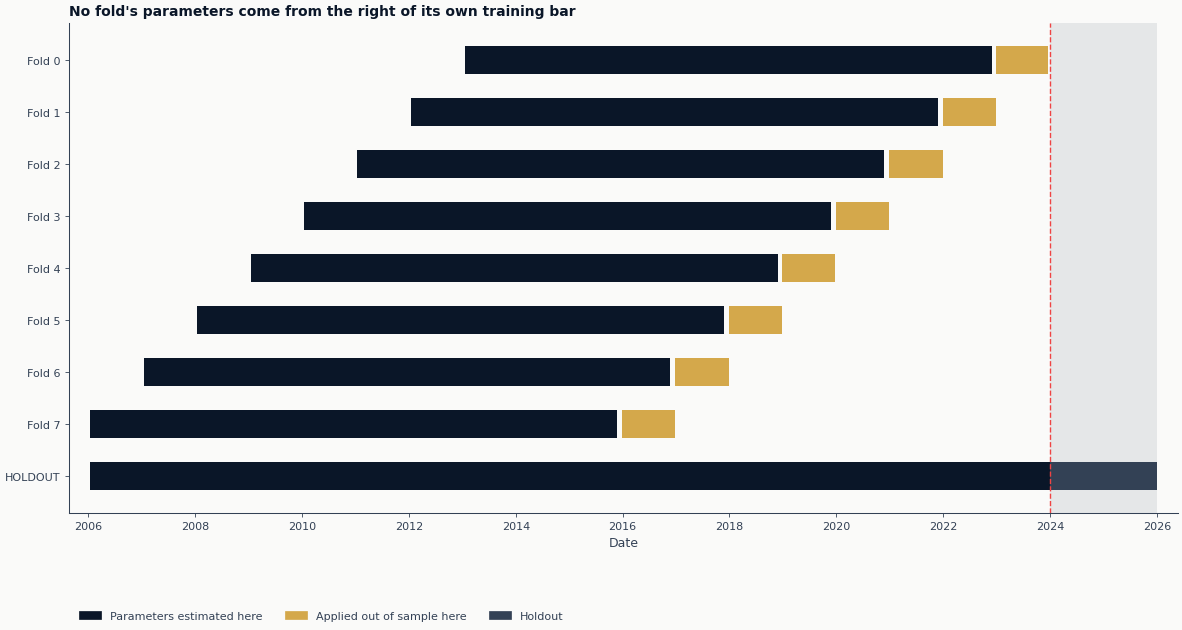

fold,train_start,train_end,val_start,val_end
str,str,str,str,str
"""0""","""2013-01-17""","""2022-11-28""","""2022-12-29""","""2023-11-29"""
"""1""","""2012-01-17""","""2021-11-26""","""2021-12-29""","""2022-12-28"""
"""2""","""2011-01-14""","""2020-11-25""","""2020-12-29""","""2021-12-28"""
"""3""","""2010-01-15""","""2019-11-26""","""2019-12-30""","""2020-12-28"""
"""4""","""2009-01-15""","""2018-11-26""","""2018-12-28""","""2019-12-27"""
"""5""","""2008-01-16""","""2017-11-24""","""2017-12-27""","""2018-12-27"""
"""6""","""2007-01-17""","""2016-11-23""","""2016-12-27""","""2017-12-26"""
"""7""","""2006-01-13""","""2015-11-24""","""2015-12-28""","""2016-12-23"""
"""HOLDOUT""","""2006-01-13""","""2024-01-01""","""2024-01-01""","""2025-12-31"""


In [8]:
fig_folds, ax = plt.subplots(figsize=(12, 0.5 * len(all_folds) + 2))

for f in all_folds:
    y = f["fold"]
    tr0, tr1 = pd.Timestamp(f["train_start"]), pd.Timestamp(f["train_end"])
    # The applied bar runs to emit_end, not val_end: the table carries every session the
    # fold is applied to, including the tail a shorter-horizon label validates on.
    va0, va1 = pd.Timestamp(f["val_start"]), pd.Timestamp(f["emit_end"])
    is_holdout = f["fold"] == len(cv_splits)
    ax.barh(y, tr1 - tr0, left=tr0, height=0.55, color=COLORS["blue"])
    ax.barh(
        y,
        va1 - va0,
        left=va0,
        height=0.55,
        color=COLORS["neutral"] if is_holdout else COLORS["amber"],
    )

ax.axvline(pd.Timestamp(HOLDOUT_START), color=COLORS["negative"], linestyle="--", linewidth=1.0)
ax.axvspan(
    pd.Timestamp(HOLDOUT_START),
    pd.Timestamp(HOLDOUT_END),
    color=COLORS["neutral"],
    alpha=0.10,
    linewidth=0,
)
ax.set_yticks([f["fold"] for f in all_folds])
ax.set_yticklabels(
    [("HOLDOUT" if f["fold"] == len(cv_splits) else f"Fold {f['fold']}") for f in all_folds]
)
ax.invert_yaxis()
ax.set_xlabel("Date")
handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS["blue"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["amber"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["neutral"]),
]
# Every row is a full-width bar, so an in-axes legend lands on top of one of them.
ax.legend(
    handles,
    ["Parameters estimated here", "Applied out of sample here", "Holdout"],
    frameon=False,
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(0.0, -0.18),
    ncol=3,
)
_span = pd.Timestamp(HOLDOUT_END) - pd.Timestamp(min(f["train_start"] for f in all_folds))
ax.set_xlim(
    pd.Timestamp(min(f["train_start"] for f in all_folds)) - _span * 0.02,
    pd.Timestamp(HOLDOUT_END) + _span * 0.02,
)
ax.set_title(
    "No fold's parameters come from the right of its own training bar",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_folds.tight_layout()
show_with_alt(
    fig_folds,
    "Nine horizontal bars, one per fold plus the holdout, each a long dark bar for the window "
    "the parameters are estimated on followed by a short amber bar for the window they are "
    "applied to unseen. Each fold starts and ends a year earlier than the one above it, and a "
    "dashed line with a shaded column marks the holdout, which no amber bar crosses.",
)

display(
    pl.DataFrame(
        [
            {
                "fold": "HOLDOUT" if f["fold"] == len(cv_splits) else str(f["fold"]),
                "train_start": str(pd.Timestamp(f["train_start"]).date()),
                "train_end": str(pd.Timestamp(f["train_end"]).date()),
                "val_start": str(pd.Timestamp(f["val_start"]).date()),
                "val_end": str(pd.Timestamp(f["val_end"]).date()),
            }
            for f in all_folds
        ]
    )
)

## C. One section per model

Three models are fitted, and each of the three sections below answers the same three questions
in the same order: what does this model infer, where were its parameters estimated, and what
stops the inference from reading forward. Each ends with an assertion that the fit window lay
inside the fold, because a claim in prose that it did is not evidence that it did.

### C.1 Regime states from a hidden Markov model

A **hidden Markov model** assumes the series is generated by a small number of unobserved
states, that the state on one session depends only on the state on the one before, and that
each state emits observations from its own distribution. Fitting it means recovering those
distributions and the probabilities of moving between states; using it means asking, for each
session, how likely each state is.

Two states are used here, and the observation on each session is a pair: that session's log
return and the realized volatility of the recent past. Two states is a modelling choice, not
a fitted one - the model is not asked how many regimes there are, it is asked to split the
market into a calm state and a stressed one and to say which is more likely on each day.

The model is fitted on the broad market rather than on each ETF. A regime in this sense is a
property of the market as a whole, not of one fund, so one hundred separately fitted models
would be one hundred noisy estimates of the same thing; and a state that means "stressed"
for one ETF and "stressed" for another only supports a cross-sectional comparison if the two
were defined identically. Every ETF therefore inherits the same regime probability on a given
session, which also means this feature can only help a model by interacting with something
that does vary across assets.

In [9]:
market = (
    prices.filter(pl.col("symbol") == "SPY")
    .sort("timestamp")
    .with_columns(
        log_ret=(pl.col("close").log().diff() * 100),
        realized_vol=(
            pl.col("close").log().diff().rolling_std(window_size=VOL_WINDOW) * 100 * np.sqrt(252)
        ),
    )
    .drop_nulls()
)
MARKET_COLS = ["log_ret", "realized_vol"]

print(
    f"Market proxy: SPY, {market.height:,} sessions from {market['timestamp'].min()} to "
    f"{market['timestamp'].max()}."
)

Market proxy: SPY, 5,010 sessions from 2006-02-02 to 2025-12-31.


### Fitting the model, and keeping the states comparable

Two practical problems come with this model, and both are handled by helpers shared across the
case studies in `case_studies/utils/temporal.py`.

The first is that fitting is a local search. The algorithm improves an initial guess until it
stops improving, and where it stops depends on where it started, so a poor start returns a
poor description of the data. `fit_hmm_kmeans_init` starts the state distributions from a
k-means partition of the observations, which is a guess the data chose, and the loop below
repeats the fit from several starting points and keeps the one with the highest likelihood.

The second is that the states come back in an arbitrary order. Nothing in the algorithm says
which of the two is state zero, so the same fitted regime can be state zero in one fold and
state one in the next - and a feature named for one of them would then mean different things
in different folds. `sort_states_by_variance` puts them in a fixed order by how dispersed
each state's observations are, so state zero is always the calm one and state one always the
stressed one.

The third is that a seeded fit is not yet a reproducible fit. Both k-means and the
expectation-maximisation steps behind it sum over the observations in parallel, and addition
in floating point is not associative, so the total depends on how the work was divided between
threads. On this data that moves the fitted parameters in their last few digits, which moves
the emitted probabilities by around $10^{-11}$ - invisible in any printed table and enough to
change the content digest of the saved file, so that two runs of identical code produce
artifacts that cannot be shown to be the same. Running the fit inside `threadpool_limits(1)`
fixes the division of work, and the fit then reproduces exactly whatever else the machine is
doing. It is worth the cost only around the fit: this model reads two columns and a few
thousand rows, so it was never gaining much from the extra threads.

The fourth choice is the one section A named. `filtered_state_probs` runs the model forward
through the series, so the probability it reports for a session is conditioned on that session
and everything before it. The library's own convenience methods return the smoothed
probabilities, conditioned on the whole window including sessions that had not happened yet,
and the same is true of its `predict`, which returns the single most likely state *sequence*
and so decides each session's state partly from what came after it. Neither can be a feature.

In [10]:
STATE_COUNT = 2
STRESS_THRESHOLD = 0.5  # With two states the posterior exceeds one half for at most one.


def regime_features(timestamps: pl.Series, filtered: np.ndarray, order: np.ndarray) -> pl.DataFrame:
    """Turn a filtered two-state posterior into the three emitted regime features.

    All three derive from the forward pass, so each session's value is a function of that
    session and its past only. The state driving the duration count is the more likely of the
    two under that posterior, not the most likely state sequence.
    """
    ordered = filtered[:, order]
    prob_stress = ordered[:, 1]
    in_stress = (prob_stress >= STRESS_THRESHOLD).astype(int)

    transition = np.abs(np.diff(prob_stress, prepend=prob_stress[0]))

    duration = np.zeros(len(in_stress))
    run = 0
    for i in range(len(in_stress)):
        run = 1 if i == 0 or in_stress[i] != in_stress[i - 1] else run + 1
        duration[i] = run

    return pl.DataFrame(
        {
            "timestamp": timestamps,
            "regime_prob_stress": prob_stress,
            "regime_transition": transition,
            "regime_log_duration": np.log1p(duration),
        }
    )

The loop fits the model on each fold's training sessions, then runs the forward pass across
the whole fold window so that the validation sessions get a probability from parameters that
never read them. It also keeps the fitted parameters themselves, which section D looks at.

In [11]:
hmm_frames = []
hmm_params = []

for fold in all_folds:
    fold_idx = fold["fold"]
    train_start, train_end = fold["train_start"], fold["train_end"]
    emit_end = fold["emit_end"]

    train = market.filter(
        (pl.col("timestamp") >= pl.lit(train_start).cast(pl.Date))
        & (pl.col("timestamp") < pl.lit(train_end).cast(pl.Date))
    )
    X_train = train.select(MARKET_COLS).to_numpy()
    if len(X_train) < 252:
        print(f"  Fold {fold_idx}: only {len(X_train)} training sessions, no regime model fitted")
        continue

    best_model, best_ll = None, -np.inf
    with threadpool_limits(limits=1):
        for seed in range(N_RESTARTS):
            try:
                candidate = fit_hmm_kmeans_init(X_train, n_states=STATE_COUNT, random_state=seed)
                ll = candidate.score(X_train)
                if ll > best_ll:
                    best_model, best_ll = candidate, ll
            except Exception:
                continue
    if best_model is None:
        print(f"  Fold {fold_idx}: regime model did not converge from any starting point")
        continue

    order = sort_states_by_variance(best_model)

    window = market.filter(
        (pl.col("timestamp") >= pl.lit(train_start).cast(pl.Date))
        & (pl.col("timestamp") <= pl.lit(emit_end).cast(pl.Date))
    )
    filtered = filtered_state_probs(best_model, window.select(MARKET_COLS).to_numpy())

    hmm_frames.append(
        regime_features(window["timestamp"], filtered, order).with_columns(
            pl.lit(fold_idx).alias("fold")
        )
    )

    calm, stress = int(order[0]), int(order[1])
    hmm_params.append(
        {
            "fold": fold_idx,
            "train_sessions": int(len(X_train)),
            "mean_ret_stress": float(best_model.means_[stress, 0]),
            "mean_vol_stress": float(best_model.means_[stress, 1]),
            "mean_vol_calm": float(best_model.means_[calm, 1]),
            "persist_stress": float(best_model.transmat_[stress, stress]),
            "persist_calm": float(best_model.transmat_[calm, calm]),
        }
    )

    print(
        f"  Fold {fold_idx}: fitted on {len(X_train):,} sessions, "
        f"{len(hmm_frames[-1]):,} sessions inferred"
    )

hmm_features = pl.concat(hmm_frames)
hmm_param_df = pl.DataFrame(hmm_params).sort("fold")
print(f"Regime features: {len(hmm_features):,} rows across {hmm_features['fold'].n_unique()} folds")

  Fold 0: fitted on 2,483 sessions, 2,752 sessions inferred


  Fold 1: fitted on 2,483 sessions, 2,757 sessions inferred


  Fold 2: fitted on 2,483 sessions, 2,757 sessions inferred


  Fold 3: fitted on 2,483 sessions, 2,757 sessions inferred


  Fold 4: fitted on 2,483 sessions, 2,757 sessions inferred


  Fold 5: fitted on 2,483 sessions, 2,757 sessions inferred


  Fold 6: fitted on 2,483 sessions, 2,757 sessions inferred


  Fold 7: fitted on 2,470 sessions, 2,744 sessions inferred


  Fold 8: fitted on 4,508 sessions, 5,010 sessions inferred
Regime features: 27,048 rows across 9 folds


The fit window has to end where the fold says it does, and the emitted window has to be the
window the fold is applied to. Asserting it is what separates a claim from a check.

In [12]:
for f in all_folds:
    fitted = hmm_param_df.filter(pl.col("fold") == f["fold"])
    if not fitted.height:
        continue
    emitted = hmm_features.filter(pl.col("fold") == f["fold"])
    assert emitted["timestamp"].min() >= pd.Timestamp(f["train_start"]).date()
    assert emitted["timestamp"].max() <= pd.Timestamp(f["emit_end"]).date()
    trainable = market.filter(
        (pl.col("timestamp") >= pl.lit(f["train_start"]).cast(pl.Date))
        & (pl.col("timestamp") < pl.lit(f["train_end"]).cast(pl.Date))
    ).height
    assert int(fitted["train_sessions"][0]) == trainable, (
        f"fold {f['fold']} fitted on {fitted['train_sessions'][0]} sessions, "
        f"{trainable} lie inside its training window"
    )
print("Every regime model was fitted inside its own training window.")

Every regime model was fitted inside its own training window.


### What the model inferred, on validation sessions

Each cross-validation fold contributes only its validation window, and the shading is that
fold's filtered probability of the stressed state - the same quantity the saved feature
carries. Every shaded band was produced by a model that had not read it.

The holdout fold is not drawn. Its features are computed and saved like every other fold's,
but looking at them now is the use the holdout is held back from, and the evaluation at the
end excludes it for the same reason.

The bands mark where the probability of the stressed state exceeds one half. That threshold
is a reading aid for the figure only; the emitted feature is the probability itself and
nothing downstream compares it to a cutoff.

Validation sessions drawn: 1,995 (2015-12-28 to 2023-11-29)


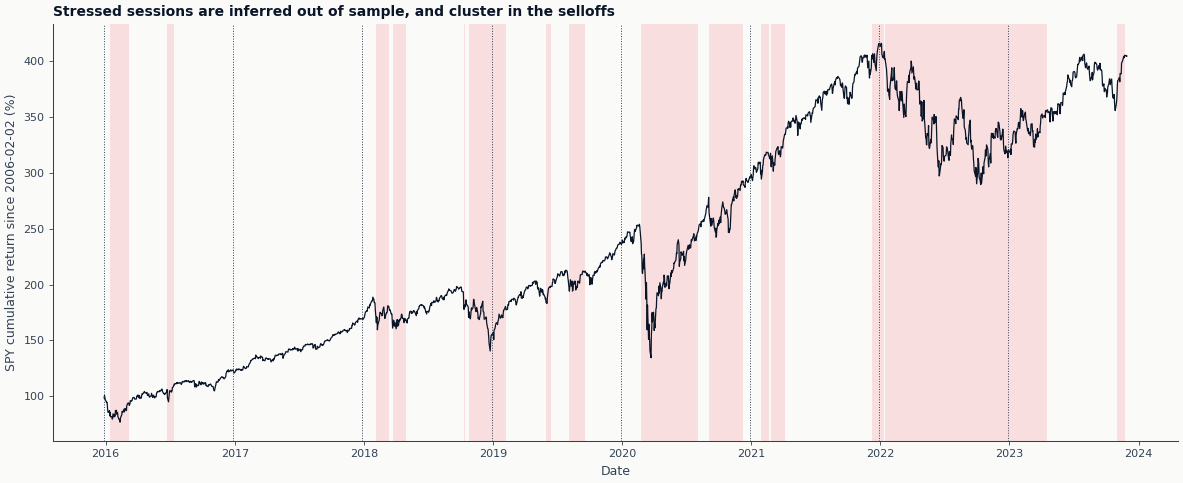

In [13]:
val_regimes = pl.concat(
    [
        hmm_features.filter(
            (pl.col("fold") == f["fold"])
            & (pl.col("timestamp") >= pl.lit(f["val_start"]).cast(pl.Date))
            & (pl.col("timestamp") <= pl.lit(f["val_end"]).cast(pl.Date))
        )
        for f in cv_splits
    ]
).sort("timestamp")

market_cum = market.with_columns(cum_ret=(pl.col("close") / pl.col("close").first() - 1) * 100)
market_val = market_cum.join(val_regimes.select("timestamp"), on="timestamp", how="semi").sort(
    "timestamp"
)
print(
    f"Validation sessions drawn: {len(val_regimes):,} "
    f"({val_regimes['timestamp'].min()} to {val_regimes['timestamp'].max()})"
)

fig_regime, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    market_val["timestamp"].to_numpy(),
    market_val["cum_ret"].to_numpy(),
    linewidth=0.9,
    color=COLORS["blue"],
)

_dates = val_regimes["timestamp"].to_numpy()
_stress = (val_regimes["regime_prob_stress"] > STRESS_THRESHOLD).to_numpy()
_in_run, _start = False, None
for _i in range(len(_stress)):
    if _stress[_i] and not _in_run:
        _start, _in_run = _dates[_i], True
    elif not _stress[_i] and _in_run:
        ax.axvspan(_start, _dates[_i], alpha=0.15, color=COLORS["negative"], linewidth=0)
        _in_run = False
if _in_run:
    ax.axvspan(_start, _dates[-1], alpha=0.15, color=COLORS["negative"], linewidth=0)

for f in cv_splits:
    ax.axvline(pd.Timestamp(f["val_start"]), color=COLORS["neutral"], linestyle=":", linewidth=0.7)

ax.set_xlabel("Date")
# The curve is the whole-history cumulative return sampled at validation sessions, so its
# baseline is the start of the price series rather than the left edge of the plot.
ax.set_ylabel(f"SPY cumulative return since {market_cum['timestamp'].min()} (%)")
ax.set_title(
    "Stressed sessions are inferred out of sample, and cluster in the selloffs",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_regime.tight_layout()
show_with_alt(
    fig_regime,
    "SPY cumulative return from 2016 to 2024 as a dark line rising from about 100 to just over "
    "400 percent, with vertical pink bands marking the sessions the regime model calls "
    "stressed. The bands sit on the drawdowns - early 2016, early 2018, late 2018, the "
    "February 2020 crash and most of 2022 - and are absent from the steady climbs between.",
)

### C.2 Fractional differencing

A price series is not stationary: its mean wanders, so a model fitted on one stretch of it
describes a different distribution from the one that generated the next stretch. The usual
repair is to take returns - to difference the log price once - which is stationary but throws
away the level entirely. Everything the series remembered about where it had been is gone.

**Fractional differencing** interpolates between the two. Differencing by an order $d$ between
zero and one applies a weighted sum of all past values, with weights that decay as they reach
further back; at $d = 0$ nothing is removed and the series is the log price, at $d = 1$ it is
the log return, and in between enough of the trend is removed to make the series stable while
some of the memory is left.

The orders are fixed in advance rather than searched for. Choosing $d$ per series by testing
which value passes a stationarity test would make the transform depend on the data it is
applied to, which is the estimation channel section A described, and it would have to be
redone inside every fold. A fixed order is purely mechanical, so no part of it can read the
future. Rate-sensitive bond and credit funds get the higher order because their log prices
carry a stronger trend; the check below is what says whether that is enough.

Ten reference ETFs are transformed rather than all hundred. These series are shared across the
panel like the regime features - every ETF receives the same ten columns - and they are chosen
to span the asset classes the universe covers, so that a model has a broad-market, a
small-cap, an international, a rates, a credit, a commodity and a property series to read.

In [14]:
REFERENCE_ETFS = {
    "SPY": (0.4, "US large-cap equities"),
    "QQQ": (0.4, "US technology equities"),
    "IWM": (0.4, "US small-cap equities"),
    "EFA": (0.4, "International developed equities"),
    "EEM": (0.4, "Emerging-market equities"),
    "TLT": (0.5, "Long-dated Treasuries"),
    "GLD": (0.4, "Gold"),
    "VNQ": (0.4, "US real estate"),
    "HYG": (0.5, "High-yield credit"),
    "LQD": (0.5, "Investment-grade credit"),
}

display(
    pl.DataFrame(
        [
            {"symbol": s, "differencing order d": d, "asset class": what}
            for s, (d, what) in REFERENCE_ETFS.items()
        ]
    )
)

symbol,differencing order d,asset class
str,f64,str
"""SPY""",0.4,"""US large-cap equities"""
"""QQQ""",0.4,"""US technology equities"""
"""IWM""",0.4,"""US small-cap equities"""
"""EFA""",0.4,"""International developed equiti…"
"""EEM""",0.4,"""Emerging-market equities"""
"""TLT""",0.5,"""Long-dated Treasuries"""
"""GLD""",0.4,"""Gold"""
"""VNQ""",0.4,"""US real estate"""
"""HYG""",0.5,"""High-yield credit"""


The transform is applied inside each fold window rather than once over the whole history. The
filter needs a run-up before it produces a value, and computing per fold keeps that run-up
inside the fold instead of carrying a value across a boundary.

In [15]:
ffd_frames = []

for fold in all_folds:
    fold_idx = fold["fold"]
    per_symbol = []
    for symbol, (d, _) in REFERENCE_ETFS.items():
        etf = (
            prices.filter(
                (pl.col("symbol") == symbol)
                & (pl.col("timestamp") >= pl.lit(fold["train_start"]).cast(pl.Date))
                & (pl.col("timestamp") <= pl.lit(fold["emit_end"]).cast(pl.Date))
            )
            .sort("timestamp")
            .select(["timestamp", "close"])
        )
        if etf.height == 0:
            continue
        per_symbol.append(
            pl.DataFrame(
                {
                    "timestamp": etf["timestamp"],
                    f"ffd_{symbol.lower()}": ffdiff(etf["close"].log(), d=d),
                }
            ).drop_nulls()
        )

    fold_frame = per_symbol[0]
    for frame in per_symbol[1:]:
        fold_frame = fold_frame.join(frame, on="timestamp", how="outer_coalesce")
    ffd_frames.append(fold_frame.sort("timestamp").with_columns(pl.lit(fold_idx).alias("fold")))
    print(f"  Fold {fold_idx}: {len(per_symbol)} series, {ffd_frames[-1].height:,} sessions")

ffd_features = pl.concat(ffd_frames)
ffd_cols = [c for c in ffd_features.columns if c.startswith("ffd_")]
print(f"Fractionally differenced series: {len(ffd_cols)}, {ffd_features.height:,} rows")

  Fold 0: 10 series, 2,752 sessions
  Fold 1: 10 series, 2,757 sessions
  Fold 2: 10 series, 2,757 sessions
  Fold 3: 10 series, 2,757 sessions


  Fold 4: 10 series, 2,757 sessions
  Fold 5: 10 series, 2,757 sessions
  Fold 6: 10 series, 2,757 sessions
  Fold 7: 10 series, 2,757 sessions


  Fold 8: 10 series, 5,023 sessions
Fractionally differenced series: 10, 27,074 rows


### Did the chosen orders reach stationarity?

The claim that these orders leave a usable series is testable, so it is tested rather than
asserted. The augmented Dickey-Fuller test asks whether a series has a unit root - whether it
wanders without returning - and a small p-value is evidence that it does not. The comparison
that matters is against the untransformed log price, which should fail the test comprehensively.

The test runs on the most recent cross-validation fold. The holdout fold covers the same ten
series over a longer window and would show nothing this one does not.

In [16]:
_last = cv_splits[0]
adf_rows = []
for symbol, (d, _) in REFERENCE_ETFS.items():
    raw = (
        prices.filter(
            (pl.col("symbol") == symbol)
            & (pl.col("timestamp") >= pl.lit(_last["train_start"]).cast(pl.Date))
            & (pl.col("timestamp") <= pl.lit(_last["val_end"]).cast(pl.Date))
        )
        .sort("timestamp")["close"]
        .log()
        .to_numpy()
    )
    differenced = (
        ffd_features.filter(pl.col("fold") == _last["fold"])[f"ffd_{symbol.lower()}"]
        .drop_nulls()
        .to_numpy()
    )
    adf_rows.append(
        {
            "symbol": symbol,
            "d": d,
            "log price p-value": float(adfuller(raw, autolag="AIC")[1]),
            "differenced p-value": float(adfuller(differenced, autolag="AIC")[1]),
        }
    )

adf_table = pl.DataFrame(adf_rows)
display(adf_table)
print(
    f"Series whose log price is judged stationary at 5%: "
    f"{int((adf_table['log price p-value'] < 0.05).sum())} of {adf_table.height}. "
    f"After differencing: {int((adf_table['differenced p-value'] < 0.05).sum())}."
)

symbol,d,log price p-value,differenced p-value
str,f64,f64,f64
"""SPY""",0.4,0.755001,5.8492e-12
"""QQQ""",0.4,0.802587,2.1209e-12
"""IWM""",0.4,0.335826,2.4582e-10
"""EFA""",0.4,0.431829,3.7390e-15
"""EEM""",0.4,0.321501,1.6399e-15
"""TLT""",0.5,0.56665,2.9367e-13
"""GLD""",0.4,0.759615,2.4649e-14
"""VNQ""",0.4,0.313352,3.5798e-11
"""HYG""",0.5,0.653522,1.2350e-15


Series whose log price is judged stationary at 5%: 0 of 10. After differencing: 10.


### C.3 Conditional volatility from a GARCH(1,1) model

**GARCH(1,1)** models the variance of a return series as evolving rather than fixed: each
session's variance is a weighted blend of a long-run level, the previous session's squared
surprise, and the previous session's variance. The two weights are what get estimated, and the
sum of them says how persistent volatility is - the closer to one, the longer a shock takes to
decay out of the forecast.

Unlike the regime model this one is fitted per ETF, because volatility is exactly the property
that differs across assets on a given session. It is what gives the output table a column that
varies across the cross-section, which is what a model ranking assets needs.

The fit-then-filter pattern is what keeps it causal. The coefficients are estimated on the
fold's training returns; they are then frozen and the variance recursion is run forward over
the whole fold window. Every value in the validation window comes from that window's own
returns fed through parameters estimated before it began.

An ETF with too little history in a fold is skipped rather than fitted on a short sample, so
the earliest folds cover fewer assets than the later ones. That is the unbalanced panel from
section B showing up in the output.

In [17]:
all_symbols = sorted(prices["symbol"].unique().to_list())
if MAX_SYMBOLS > 0:
    all_symbols = all_symbols[:MAX_SYMBOLS]


def fit_garch_fold(
    prices_df: pl.DataFrame, symbols: list[str], fold: dict, min_obs: int
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Fit GARCH(1,1) per symbol on one fold's training returns, then filter the fold window.

    Returns the annualized conditional volatility for every session in the fold window, and the
    frozen coefficients the filter ran with.
    """
    fold_idx = fold["fold"]
    results, params = [], []
    n_fitted = n_skipped = 0

    for sym in symbols:
        window = (
            prices_df.filter(
                (pl.col("symbol") == sym)
                & (pl.col("timestamp") >= pl.lit(fold["train_start"]).cast(pl.Date))
                & (pl.col("timestamp") <= pl.lit(fold["emit_end"]).cast(pl.Date))
            )
            .sort("timestamp")
            .with_columns(ret=pl.col("close").pct_change())
            .drop_nulls(subset=["ret"])
        )
        train = window.filter(pl.col("timestamp") < pl.lit(fold["train_end"]).cast(pl.Date))
        if train.height < min_obs:
            n_skipped += 1
            continue

        try:
            fitted = arch_model(
                (train["ret"] * 100).to_numpy(),
                mean="Constant",
                vol="GARCH",
                p=1,
                q=1,
                dist="Normal",
            ).fit(disp="off", show_warning=False)

            frozen = arch_model(
                (window["ret"] * 100).to_numpy(),
                mean="Constant",
                vol="GARCH",
                p=1,
                q=1,
                dist="Normal",
            ).fix(fitted.params)

            params.append(
                {
                    "symbol": sym,
                    "train_sessions": train.height,
                    "omega": float(fitted.params.get("omega", np.nan)),
                    "alpha": float(fitted.params.get("alpha[1]", np.nan)),
                    "beta": float(fitted.params.get("beta[1]", np.nan)),
                }
            )
            results.append(
                pl.DataFrame(
                    {
                        "timestamp": window["timestamp"].to_list(),
                        "symbol": [sym] * window.height,
                        # The recursion runs on percent returns; restore decimal and annualize.
                        "garch_cond_vol": frozen.conditional_volatility * np.sqrt(252) / 100,
                        "fold": [fold_idx] * window.height,
                    }
                ).drop_nulls()
            )
            n_fitted += 1
        except Exception:
            n_skipped += 1

    print(f"  Fold {fold_idx}: {n_fitted} of {len(symbols)} ETFs fitted, {n_skipped} skipped")
    if not results:
        raise ValueError(
            f"fold {fold_idx}: no ETF had {min_obs} training sessions, so the fold would emit "
            "a conditional-volatility column that is null everywhere"
        )
    return (
        pl.concat(results),
        pl.DataFrame(params).with_columns(pl.lit(fold_idx).alias("fold")),
    )

In [18]:
garch_frames, garch_param_frames = [], []
for fold in all_folds:
    values, params = fit_garch_fold(prices, all_symbols, fold, GARCH_MIN_OBS)
    garch_frames.append(values)
    garch_param_frames.append(params)

garch_features = pl.concat(garch_frames)
garch_param_df = pl.concat(garch_param_frames)
GARCH_COLS = ["garch_cond_vol"]
print(
    f"Conditional volatility: {garch_features.height:,} rows, "
    f"{garch_features['symbol'].n_unique()} ETFs, {garch_features['fold'].n_unique()} folds"
)

  Fold 0: 100 of 100 ETFs fitted, 0 skipped


  Fold 1: 100 of 100 ETFs fitted, 0 skipped


  Fold 2: 100 of 100 ETFs fitted, 0 skipped


  Fold 3: 99 of 100 ETFs fitted, 1 skipped


  Fold 4: 99 of 100 ETFs fitted, 1 skipped


  Fold 5: 99 of 100 ETFs fitted, 1 skipped


  Fold 6: 98 of 100 ETFs fitted, 2 skipped


  Fold 7: 98 of 100 ETFs fitted, 2 skipped


  Fold 8: 100 of 100 ETFs fitted, 0 skipped
Conditional volatility: 2,559,761 rows, 100 ETFs, 9 folds


As with the regime model, the fit window is asserted rather than described: every set of
coefficients came from sessions strictly inside its fold's training window, and no emitted
value falls outside the fold window.

In [19]:
for f in all_folds:
    fold_params = garch_param_df.filter(pl.col("fold") == f["fold"])
    fold_values = garch_features.filter(pl.col("fold") == f["fold"])
    assert fold_values["timestamp"].min() >= pd.Timestamp(f["train_start"]).date()
    assert fold_values["timestamp"].max() <= pd.Timestamp(f["emit_end"]).date()
    trainable = (
        prices.filter(
            (pl.col("timestamp") >= pl.lit(f["train_start"]).cast(pl.Date))
            & (pl.col("timestamp") < pl.lit(f["train_end"]).cast(pl.Date))
            & pl.col("symbol").is_in(fold_params["symbol"].to_list())
        )
        .group_by("symbol")
        .agg(pl.len().alias("n"))
    )
    # One session is lost to the return difference at the window's first bar.
    joined = fold_params.join(trainable, on="symbol", how="inner")
    assert joined.height == fold_params.height, f"fold {f['fold']} lost a symbol on the join"
    assert (joined["train_sessions"] == joined["n"] - 1).all(), (
        f"fold {f['fold']} fitted on a different session count than its training window holds"
    )
print("Every GARCH fit used its own fold's training sessions and no others.")

Every GARCH fit used its own fold's training sessions and no others.


## D. Fit stability across folds

The training windows overlap heavily - each rolls a year further back over a ten-year span -
so the coefficients should move slowly. Whether they move at all is the question that decides
refitting: parameters identical across folds would mean per-fold refitting bought nothing but
cost, while parameters that swing are a warning about any feature depending on them.

Both models are refitted from scratch at every fold boundary, and neither updates between
boundaries. Inside a fold the parameters are frozen and only the data flowing through them
changes.

In [20]:
display(hmm_param_df)

garch_param_summary = (
    garch_param_df.with_columns(persistence=pl.col("alpha") + pl.col("beta"))
    .group_by("fold")
    .agg(
        pl.col("alpha").median().alias("alpha_median"),
        pl.col("beta").median().alias("beta_median"),
        pl.col("persistence").median().alias("persistence_median"),
        pl.len().alias("n_fits"),
    )
    .sort("fold")
)
display(garch_param_summary)

fold,train_sessions,mean_ret_stress,mean_vol_stress,mean_vol_calm,persist_stress,persist_calm
i64,i64,f64,f64,f64,f64,f64
0,2483,-0.001908,23.133686,9.395874,0.981717,0.988984
1,2483,0.018504,23.437268,9.806582,0.976128,0.991782
2,2483,0.011937,24.690028,9.807978,0.979503,0.990911
3,2483,0.020792,20.32038,9.353015,0.976363,0.987577
4,2483,0.039412,22.035615,9.509153,0.981672,0.988641
5,2483,-0.050049,30.869491,11.290467,0.982522,0.994207
6,2483,-0.04251,31.993726,12.420573,0.982223,0.994047
7,2470,-0.053558,31.806785,11.991265,0.983275,0.994324
8,4508,-0.029604,27.130923,10.810631,0.983984,0.992108


fold,alpha_median,beta_median,persistence_median,n_fits
i32,f64,f64,f64,u32
0,0.121726,0.844124,0.975567,100
1,0.126996,0.832646,0.962374,100
2,0.129102,0.833299,0.969484,100
3,0.100106,0.871268,0.977065,99
4,0.09226,0.887738,0.984431,99
5,0.096558,0.887651,0.989214,99
6,0.100186,0.881154,0.985083,98
7,0.088251,0.898581,0.988452,98
8,0.104275,0.878117,0.986854,100


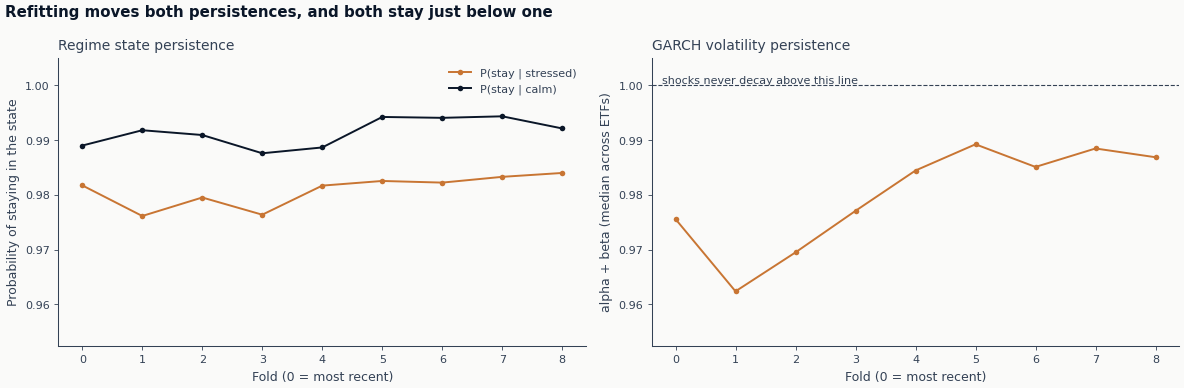

In [21]:
fig_stab, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4))

ax_l.plot(
    hmm_param_df["fold"],
    hmm_param_df["persist_stress"],
    marker="o",
    color=COLORS["copper"],
    label="P(stay | stressed)",
)
ax_l.plot(
    hmm_param_df["fold"],
    hmm_param_df["persist_calm"],
    marker="o",
    color=COLORS["blue"],
    label="P(stay | calm)",
)
ax_l.set_xlabel("Fold (0 = most recent)")
ax_l.set_ylabel("Probability of staying in the state")
ax_l.legend(frameon=False, fontsize=8)
ax_l.set_title("Regime state persistence", loc="left", fontsize=10)

ax_r.plot(
    garch_param_summary["fold"],
    garch_param_summary["persistence_median"],
    marker="o",
    color=COLORS["copper"],
)
ax_r.axhline(1.0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax_r.annotate(
    "shocks never decay above this line",
    xy=(0.02, 1.0),
    xycoords=("axes fraction", "data"),
    va="bottom",
    fontsize=8,
    color=COLORS["neutral"],
)
ax_r.set_xlabel("Fold (0 = most recent)")
ax_r.set_ylabel("alpha + beta (median across ETFs)")
ax_r.set_title("GARCH volatility persistence", loc="left", fontsize=10)

# Both panels carry a probability-scale persistence, so they share limits. Letting each
# autoscale makes a flat line and a moving one look equally dramatic.
_lo = min(
    float(hmm_param_df["persist_stress"].min()),
    float(hmm_param_df["persist_calm"].min()),
    float(garch_param_summary["persistence_median"].min()),
)
for _ax in (ax_l, ax_r):
    _ax.set_ylim(_lo - 0.01, 1.005)

fig_stab.suptitle(
    "Refitting moves both persistences, and both stay just below one",
    x=0.01,
    ha="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_stab.tight_layout()
show_with_alt(
    fig_stab,
    "Two panels against fold number, 0 being the most recent. On the left the probability of "
    "staying in each regime state, calm near 0.99 and stressed near 0.98, both moving by less "
    "than 0.01 across the nine refits. On the right the GARCH persistence, alpha plus beta, "
    "rising from about 0.962 at fold 1 to about 0.989 and staying below the dashed line at "
    "one, above which shocks would never decay.",
)

The two persistences are both numbers close to one, and they are not the same kind of number.
A regime self-transition probability $p$ says how long a state lasts: the expected run is
$1/(1-p)$ sessions. A GARCH coefficient sum says how a variance shock decays: the fraction of
it still present after $k$ sessions is $(\alpha+\beta)^k$, so the number of sessions after
which half of it is left is $\ln(1/2)/\ln(\alpha+\beta)$. Converted to sessions they become
readable as statements about the market rather than as coefficients, and both are printed
below alongside the ranges.

What decides the refit cadence is a different quantity, and it is worth keeping the two apart.
How long a regime lasts, or how long a shock takes to decay, is what the fitted model says
about the world; a model can describe fast-moving states and still have parameters that never
need re-estimating. The cadence question is how far the parameters themselves move from one
fold to the next. Parameters identical across folds would say refitting bought nothing;
parameters that swing would say any feature depending on them inherits that movement. The two
ranges below are that measurement, and the figure above is its shape.

In [22]:
def _range(series: pl.Series) -> float:
    return float(series.max() - series.min())


hmm_spread = max(_range(hmm_param_df["persist_stress"]), _range(hmm_param_df["persist_calm"]))
garch_spread = _range(garch_param_summary["persistence_median"])
print(f"Widest regime persistence range across folds: {hmm_spread:.4f}")
print(f"GARCH median persistence range across folds:  {garch_spread:.4f}")

_p_stress = hmm_param_df["persist_stress"]
_p_calm = hmm_param_df["persist_calm"]
_p_garch = garch_param_summary["persistence_median"]
print(
    f"Expected run in the stressed state: {1 / (1 - _p_stress.max()):.0f} sessions at the most "
    f"persistent fold, {1 / (1 - _p_stress.min()):.0f} at the least."
)
print(
    f"Expected run in the calm state: {1 / (1 - _p_calm.max()):.0f} sessions at the most "
    f"persistent fold, {1 / (1 - _p_calm.min()):.0f} at the least."
)
print(
    f"GARCH variance-shock half-life: {np.log(0.5) / np.log(_p_garch.max()):.0f} sessions at the "
    f"most persistent fold, {np.log(0.5) / np.log(_p_garch.min()):.0f} at the least."
)

Widest regime persistence range across folds: 0.0079
GARCH median persistence range across folds:  0.0268
Expected run in the stressed state: 62 sessions at the most persistent fold, 42 at the least.
Expected run in the calm state: 176 sessions at the most persistent fold, 80 at the least.
GARCH variance-shock half-life: 64 sessions at the most persistent fold, 18 at the least.


Across the nine folds the regime model's probability of staying in a state moves by at most
0.0079 - from 0.9761 to 0.9840 for the stressed state, and from 0.9876 to 0.9943 for the calm
one. The median GARCH persistence moves by 0.0268, from 0.9624 to 0.9892. Refitting therefore
lands close to the previous fold's answer every time: over this sample the annual refit is not
correcting a parameter that had drifted far. Whether a longer interval would still be safe is
a question about more history than this notebook reads, and it does not answer it.

Read as descriptions of the market rather than as coefficients, the same fits put a stressed
regime at an expected 42 to 62 sessions and a calm one at 80 to 176, against a variance shock
that is half gone after 18 to 64.

## E. Combine and emit

The regime and differenced-price features are one value per session, shared by every ETF; the
conditional volatility is one value per ETF per session. They are combined onto a panel keyed
by fold, session and symbol - the fold is part of the key because the same session appears in
several folds with different values, which is the whole point of the table.

Four things are checked before anything is written. The key is unique, so no downstream join
can silently multiply rows. Every fold that was asked for is present. Every session-and-symbol
the price panel offers inside a fold window is in the output for that fold, so no row was lost
on the way through the joins. And the column set is exactly what Chapter 11 expects to read.

In [23]:
panels = []
for fold in all_folds:
    fold_idx = fold["fold"]
    skeleton = (
        prices.filter(
            (pl.col("timestamp") >= pl.lit(fold["train_start"]).cast(pl.Date))
            & (pl.col("timestamp") <= pl.lit(fold["emit_end"]).cast(pl.Date))
        )
        .select(["timestamp", "symbol"])
        .unique()
        .with_columns(pl.lit(fold_idx).alias("fold"))
    )
    date_level = (
        hmm_features.filter(pl.col("fold") == fold_idx)
        .drop("fold")
        .join(
            ffd_features.filter(pl.col("fold") == fold_idx).drop("fold"),
            on="timestamp",
            how="outer_coalesce",
        )
    )
    panels.append(
        skeleton.join(date_level, on="timestamp", how="left").join(
            garch_features.filter(pl.col("fold") == fold_idx).drop("fold"),
            on=["timestamp", "symbol"],
            how="left",
        )
    )

model_based = pl.concat(panels).sort(["fold", "timestamp", "symbol"])
KEY_COLS = ["fold", "timestamp", "symbol"]
FEATURE_COLS = [c for c in model_based.columns if c not in KEY_COLS]

In [24]:
assert model_based.select(KEY_COLS).is_duplicated().sum() == 0, (
    "the panel key repeats; a downstream join would multiply rows"
)
assert sorted(model_based["fold"].unique().to_list()) == [f["fold"] for f in all_folds], (
    "a fold is missing from the emitted panel"
)
expected_rows = sum(
    prices.filter(
        (pl.col("timestamp") >= pl.lit(f["train_start"]).cast(pl.Date))
        & (pl.col("timestamp") <= pl.lit(f["emit_end"]).cast(pl.Date))
    )
    .select(["timestamp", "symbol"])
    .unique()
    .height
    for f in all_folds
)
assert model_based.height == expected_rows, (
    f"emitted {model_based.height:,} rows against {expected_rows:,} session-symbol pairs "
    "inside the fold windows"
)

Every configured label reads this table by fold number, so every configured label's validation
window has to lie inside the fold that carries it. A model whose label is not the primary one
otherwise finds no features for the tail of its own validation window - not wrong values, no
values - which is the coverage shortfall that made `11a_pca` refuse the 5-session label.

In [25]:
sessions = prices.select("timestamp").unique()
for label in configured_labels(CASE_STUDY_ID):
    label_folds = modeling_fold_boundaries(CASE_STUDY_ID, label)
    if label_folds is None:
        continue
    for split in label_folds:
        wanted = sessions.filter(
            (pl.col("timestamp") >= pl.lit(split["val_start"]).cast(pl.Date))
            & (pl.col("timestamp") <= pl.lit(split["val_end"]).cast(pl.Date))
        )["timestamp"]
        carried = model_based.filter(pl.col("fold") == split["fold"])["timestamp"].unique()
        missing = wanted.is_in(carried).not_().sum()
        assert missing == 0, (
            f"fold {split['fold']} carries {len(wanted) - missing} of {len(wanted)} sessions in "
            f"{label}'s validation window; a model on that label would read no features for the "
            f"last {missing}"
        )
print(
    f"Every configured label's validation window is covered by the fold that carries it: "
    f"{', '.join(configured_labels(CASE_STUDY_ID))}."
)
EXPECTED_COLUMNS = [
    "fold",
    "timestamp",
    "symbol",
    "regime_prob_stress",
    "regime_transition",
    "regime_log_duration",
    *[f"ffd_{s.lower()}" for s in REFERENCE_ETFS],
    "garch_cond_vol",
]
assert sorted(model_based.columns) == sorted(EXPECTED_COLUMNS), (
    f"column set changed: {sorted(set(model_based.columns) ^ set(EXPECTED_COLUMNS))}"
)
print(
    f"{model_based.height:,} rows, {len(FEATURE_COLS)} features, "
    f"{model_based['symbol'].n_unique()} ETFs, {model_based['fold'].n_unique()} folds, "
    "one row per fold-session-symbol."
)

Every configured label's validation window is covered by the fold that carries it: fwd_ret_21d, fwd_ret_5d.
2,562,675 rows, 14 features, 100 ETFs, 9 folds, one row per fold-session-symbol.


Coverage is reported over every row about to be written, holdout fold included, because it is
a check on the file rather than a reading of the market. The distribution summaries beside it
are restricted to the cross-validation folds: a mean and a spread are a description of what
the features look like, and that description is not something to form expectations from while
the holdout is still held back.

In [26]:
_dev = model_based.filter(pl.col("fold") != holdout_fold["fold"])
display(
    pl.DataFrame(
        [
            {
                "feature": col,
                "rows with a value": model_based[col].drop_nulls().len(),
                "coverage": model_based[col].drop_nulls().len() / model_based.height,
                "mean (CV folds)": _dev[col].drop_nulls().mean(),
                "std (CV folds)": _dev[col].drop_nulls().std(),
            }
            for col in FEATURE_COLS
        ]
    )
)

feature,rows with a value,coverage,mean (CV folds),std (CV folds)
str,i64,f64,f64,f64
"""regime_prob_stress""",2561141,0.999401,0.315595,0.450832
"""regime_transition""",2561141,0.999401,0.020116,0.087382
"""regime_log_duration""",2561141,0.999401,3.918176,1.357356
"""ffd_spy""",2562675,1.0,0.252675,0.145888
"""ffd_qqq""",2562675,1.0,0.229047,0.118493
…,…,…,…,…
"""ffd_gld""",2562675,1.0,0.234527,0.157005
"""ffd_vnq""",2562675,1.0,0.189697,0.110408
"""ffd_hyg""",2516067,0.981813,0.095669,0.094607


The table is written with a digest sidecar beside it: a short string computed from the values,
so that two files holding the same numbers get the same string and any changed number gets a
different one. It records the digests of the inputs too, which is what turns it into a chain -
a later stage can see not only that the feature values changed but that they changed because
something upstream did. The label file is an input here even though no label enters a feature,
because the label file is what fixes the fold boundaries, and the fold boundaries decide which
sessions each model was estimated on.

In [27]:
record = write_artifact(
    model_based,
    FEATURES_DIR / "model_based.parquet",
    keys=KEY_COLS,
    written_by=f"case_studies/{CASE_STUDY_ID}/04_model_based_features.py",
    inputs={
        "load_etfs": value_digest(prices),
        f"labels/{PRIMARY_LABEL}.parquet": value_digest(labels),
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'model_based.parquet')}")
print(f"  digest {record['digest']}, {record['n_rows']:,} rows")

Wrote case_studies/etfs/features/model_based.parquet
  digest dd180bf8e3784047, 2,562,675 rows


## F. Incremental evaluation

The last question is whether these features order the cross-section of forward returns at all.
The **information coefficient** is the rank correlation between a feature and the return that
follows, computed across the assets scored on one session and then averaged over sessions. It
is a screen and not a decision: nothing here drops a feature, and the comparison against the
stage-03 arithmetic features is made in [`05_evaluation`](05_evaluation.ipynb).

Only validation sessions of the cross-validation folds are scored. Training sessions would be
measuring how well a model describes what it was fitted on, and the holdout fold is excluded
because reading it here is the use it is held back from.

In [28]:
val_slices = [
    model_based.filter(
        (pl.col("fold") == f["fold"])
        & (pl.col("timestamp") >= pl.lit(f["val_start"]).cast(pl.Date))
        & (pl.col("timestamp") <= pl.lit(f["val_end"]).cast(pl.Date))
    )
    for f in cv_splits
]
val_features = pl.concat(val_slices)

scored = val_features.join(labels, on=["timestamp", "symbol"], how="inner").drop_nulls(
    subset=[PRIMARY_LABEL]
)
# An inner join can lose rows in either direction; say how many and why rather than let it pass.
print(
    f"{val_features.height:,} validation rows, of which {scored.height:,} carry a resolved "
    f"{PRIMARY_LABEL}; {val_features.height - scored.height:,} do not, being the sessions whose "
    "forward window runs past the end of the price history or whose ETF was not yet quoting."
)
print(
    f"{scored['symbol'].n_unique()} ETFs scored across {scored['timestamp'].n_unique():,} sessions."
)

198,877 validation rows, of which 198,877 carry a resolved fwd_ret_21d; 0 do not, being the sessions whose forward window runs past the end of the price history or whose ETF was not yet quoting.
100 ETFs scored across 1,995 sessions.


The conditional volatility differs across ETFs on a session, so its information coefficient is
a genuine cross-sectional rank correlation. The regime and differenced-price features do not -
every ETF carries the same value on a session - so a cross-sectional correlation on them is
zero by construction, and they are measured instead as a time-series correlation against the
average forward return of the panel. That is a statement about timing the market rather than
about ranking within it, and the two numbers are not comparable to each other.

Both need a standard error that accounts for overlapping observations. Consecutive sessions share
most of their forward window, so treating them as independent would overstate the evidence by
a wide margin. The cross-sectional series is corrected with a heteroskedasticity- and
autocorrelation-consistent estimator, given the label horizon as its lag; the time-series ones
use a stationary bootstrap, which resamples blocks rather than points so that the dependence
inside a block is preserved.

The bootstrap draws its blocks from NumPy's global random stream, so it is seeded immediately
before the loop. Without that the p-values move a little on every execution, and the count of
features the multiplicity correction retains moves with them, on identical coefficients.

In [29]:
DATE_LEVEL_COLS = [c for c in FEATURE_COLS if c not in GARCH_COLS]
feature_stats = {}

for feat in GARCH_COLS:
    rankable = scored.filter(pl.col(feat).is_not_null())
    ic_series = cross_sectional_ic_series(
        rankable,
        rankable,
        pred_col=feat,
        ret_col=PRIMARY_LABEL,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=MIN_CROSS_SECTION,
    )
    # A session below the floor comes back as a row with a null coefficient rather than as no
    # row at all, so the guard has to count coefficients and not rows - otherwise a universe
    # too narrow to rank would still reach the correction below, as an all-null series.
    ic_series = ic_series.filter(pl.col("ic").is_not_null() & pl.col("ic").is_finite())
    print(f"{feat}: {ic_series.height:,} sessions carry a cross-sectional coefficient")
    if ic_series.height < MIN_IC_SESSIONS:
        print(f"  fewer than {MIN_IC_SESSIONS}; not enough to correct for serial dependence")
        continue
    stats = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=LABEL_HORIZON_DAYS)
    feature_stats[feat] = {
        "ic": stats["mean_ic"],
        "t_stat": stats["t_stat"],
        "p_value": stats["p_value"],
        "se": stats["hac_se"],
    }

garch_cond_vol: 1,995 sessions carry a cross-sectional coefficient


In [30]:
panel_return = (
    scored.group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).mean().alias("panel_ret"))
    .sort("timestamp")
)
# Validation windows do not overlap, so one row per session is well defined; `keep="first"`
# makes that explicit rather than leaving the choice to row order.
date_series = (
    val_features.select(["timestamp", *DATE_LEVEL_COLS])
    .unique(subset=["timestamp"], keep="first")
    .sort("timestamp")
    .join(panel_return, on="timestamp", how="inner")
    .drop_nulls()
)

np.random.seed(SEED)
for feat in DATE_LEVEL_COLS:
    x = date_series[feat].to_numpy()
    y = date_series["panel_ret"].to_numpy()
    keep = ~(np.isnan(x) | np.isnan(y))
    if keep.sum() < MIN_IC_SESSIONS:
        continue
    result = robust_ic(x[keep], y[keep], return_details=True)
    feature_stats[feat] = {
        "ic": result["ic"],
        "t_stat": result.get("t_stat", 0.0),
        "p_value": result.get("p_value"),
        "se": result.get("bootstrap_std", result.get("bootstrap_se", 0.0)),
    }

Every feature above was screened against the same label on the same sessions, so reading the
p-values one at a time would find something significant sooner or later whatever the features
were worth. The Benjamini-Hochberg procedure adjusts the whole set at once, controlling the
share of the retained features expected to be false rather than the chance of any single false
positive.

In [31]:
evaluation = pl.DataFrame(
    [
        {
            "feature": feat,
            "kind": "cross-sectional" if feat in GARCH_COLS else "time-series",
            "ic": s["ic"],
            "t_stat": s["t_stat"],
            "p_value": s["p_value"],
            "se": s["se"],
        }
        for feat, s in feature_stats.items()
    ]
).sort("ic", descending=True)

_p = evaluation["p_value"].to_list()
if evaluation.height and all(v is not None for v in _p):
    _fdr = benjamini_hochberg_fdr(_p, alpha=0.05, return_details=True)
    evaluation = evaluation.with_columns(retained=pl.Series(_fdr["rejected"].tolist()))
else:
    evaluation = evaluation.with_columns(retained=pl.lit(False, dtype=pl.Boolean))
n_retained = int(evaluation.filter(pl.col("retained")).height)

display(evaluation)
print(f"Retained by Benjamini-Hochberg at 5%: {n_retained} of {evaluation.height}")

feature,kind,ic,t_stat,p_value,se,retained
str,str,f64,f64,f64,f64,bool
"""regime_prob_stress""","""time-series""",0.202577,2.348098,0.006,0.086273,true
"""ffd_tlt""","""time-series""",0.189477,2.627903,0.0,0.072102,true
"""ffd_lqd""","""time-series""",0.139792,1.87956,0.017,0.074375,true
"""ffd_gld""","""time-series""",0.069414,0.857549,0.321,0.080944,false
"""garch_cond_vol""","""cross-sectional""",0.068652,2.522187,0.01174,0.027219,true
…,…,…,…,…,…,…
"""ffd_qqq""","""time-series""",-0.142454,-1.827454,0.043,0.077952,false
"""ffd_vnq""","""time-series""",-0.17798,-2.566616,0.009,0.069344,true
"""ffd_efa""","""time-series""",-0.182395,-2.52877,0.004,0.072128,true


Retained by Benjamini-Hochberg at 5%: 8 of 14


The bars carry no interval, because the two kinds of coefficient are estimated with different
machinery and a shared error bar would invite a comparison the numbers do not support. The
standard errors are in the table above, and the `kind` column says which is which.

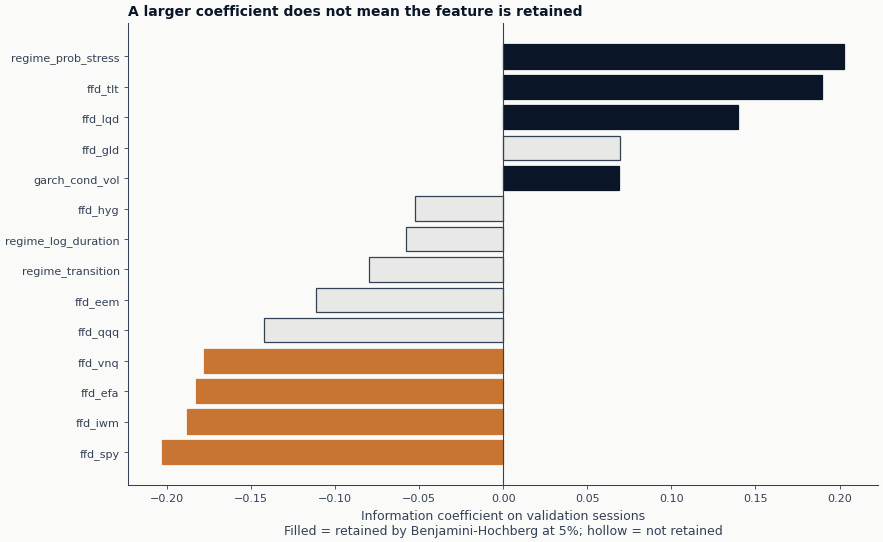

In [32]:
ordered = evaluation.sort("ic")
bar_fill = [
    (COLORS["blue"] if row["ic"] >= 0 else COLORS["copper"])
    if row["retained"]
    else COLORS["silver_muted"]
    for row in ordered.to_dicts()
]
bar_edge = [
    (COLORS["blue"] if row["ic"] >= 0 else COLORS["copper"])
    if row["retained"]
    else COLORS["neutral"]
    for row in ordered.to_dicts()
]

fig_ic, ax = plt.subplots(figsize=(9, max(3.0, 0.4 * ordered.height)))
ax.barh(
    ordered["feature"].to_list(),
    ordered["ic"].to_numpy(),
    color=bar_fill,
    edgecolor=bar_edge,
    linewidth=0.9,
)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xlabel(
    "Information coefficient on validation sessions\n"
    "Filled = retained by Benjamini-Hochberg at 5%; hollow = not retained"
)
ax.set_title(
    "A larger coefficient does not mean the feature is retained",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_ic.tight_layout()
show_with_alt(
    fig_ic,
    "Fourteen horizontal bars of information coefficient on validation sessions, sorted from "
    "about +0.20 for the stressed-regime probability down to about -0.20 for the fractionally "
    "differenced SPY series. Filled bars are retained by Benjamini-Hochberg at 5 percent and "
    "hollow ones are not, and the two do not follow the ordering: a hollow bar near +0.07 sits "
    "above a filled one of the same size.",
)

The screen runs on 198,877 validation rows - 100 ETFs across 1,995 sessions - and
Benjamini-Hochberg retains 8 of the 14 features at 5%. The two largest coefficients are near
mirror images: 0.2026 for the filtered probability of the stressed state, and -0.2028 for the
fractionally differenced S&P 500 price. Magnitude is not what decides retention. `ffd_gld` at
0.0694 is dropped while `garch_cond_vol` at 0.0687 is kept, because the cross-sectional
coefficient is estimated across a hundred ETFs on every session and carries a standard error
of 0.0272, against 0.0809 for the date-level one.

## Key takeaways

- **Fit inside the fold, and say where the fit stopped with an assertion.** Every model here is
  estimated on one fold's training sessions and applied forward from there. The check that the
  fit window lies inside the fold is executed, not described, because a leaked fit produces a
  notebook that runs clean and agrees with itself.
- **Filtered, never smoothed.** Given fixed parameters there is usually more than one way to
  run a model over a series, and the more accurate one generally reads the whole series. Look
  for the method that conditions on the past alone; if the library's convenient default is the
  other one, that default is a look-ahead.
- **Fix what you can rather than estimating it.** The differencing orders are chosen in advance
  so that no part of the transform reads the data, which removes an entire leak channel instead
  of managing it. Where a choice is fixed rather than fitted, test that it was a workable
  choice - here with a stationarity test whose result is shown rather than asserted.
- **Make the fold boundaries come from one place.** The fold number written into this table is
  a join key, and it only means something if the code reading it back computes the same
  windows. Deriving them from the same file with the same call is what guarantees that.
- **Refit at a stated cadence and look at what refitting moved.** These parameters are
  re-estimated at every fold boundary and frozen in between. Plotting them across folds is what
  tells you whether that cadence is buying anything.
- **Check the panel before writing it.** A unique key, the expected folds, a row count
  reconciled against the input, and a frozen column set are four assertions that cost nothing
  and catch the join defects that are otherwise found several notebooks downstream.

### Known limitations

- **The regime feature is the same number for every ETF on a session.** It can only help a
  model that ranks assets by interacting with something that does vary across them; on its own
  it carries no cross-sectional information at all, and its coefficient here is measured
  against the panel average rather than against the cross-section.
- **Each fold's inference restarts at the fold's first session.** The forward pass has no state
  to carry in at that point, and the regime duration counter starts from one, so the earliest
  sessions of a fold understate how long the prevailing regime has run. Those sessions are deep
  inside the training window and are not what the evaluation scores, but they are in the file.
- **The holdout fold is estimated on a wider window than the cross-validation folds.** Those
  roll a ten-year window; the holdout fold trains on everything before the holdout begins,
  which is the whole sample. More history is a better estimate and no future is read, but the
  holdout features come from a differently-specified estimator than the ones the validation
  coefficients above were measured on.
- **Ten reference series stand in for the asset classes in the panel.** They were chosen to
  span the universe rather than derived from it, and a different ten would give a model
  different columns to read.
- **The evaluation is univariate.** Each feature is screened alone, so it says nothing about
  what any of them add on top of each other or on top of the arithmetic features from stage 03.
  That comparison is the subject of [`05_evaluation`](05_evaluation.ipynb).